# WCO Model MobileNetV2 -> alpha = 0.35 -> 160x160
**Output:** contamination + colour
**Inference:** FastAPI server (Keras float32)
**ESP32:** sadece görüntü toplar, inference yok

In [1]:
# ── 1. Drive mount ────────────────────────────────────────────────
import os
from google.colab import drive

drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/cropped160'
SAVE_PATH = '/content/drive/MyDrive/models/MobileNetV2_a035.keras'

os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ── 2. Import ─────────────────────────────────────────────────────
import os, re
import numpy as np
import tensorflow as tf
import keras
from keras import layers, Model
from keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split

IMG_SIZE   = 160
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE

print('TF version:', tf.__version__)

TF version: 2.19.0


In [3]:
# ── 3. Label parse ────────────────────────────────────────────────
# contamination = min(1, turbidity + particle)
# colour ayrı kalır
def parse_label(filename):
    m = re.match(r't(\d)[_-]p(\d)[_-]c(\d)', filename)
    if not m:
        return None
    t, p, c = int(m.group(1)), int(m.group(2)), int(m.group(3))
    contamination = min(1, t + p)
    return np.array([contamination, c], dtype=np.float32)

all_files, all_labels = [], []

for fname in sorted(os.listdir(DRIVE_DIR)):
    if not (fname.endswith('.jpg') or fname.endswith('.jpeg')):
        continue

    lbl = parse_label(fname)
    if lbl is None:
        print(f'SKIP: {fname}')
        continue
    all_files.append(os.path.join(DRIVE_DIR, fname))
    all_labels.append(lbl)

all_labels = np.array(all_labels, dtype=np.float32)
print(f'Toplam        : {len(all_files)} görüntü')
print(f'contamination : {all_labels[:,0].sum():.0f} pozitif')
print(f'colour        : {all_labels[:,1].sum():.0f} pozitif')

Toplam        : 296 görüntü
contamination : 216 pozitif
colour        : 145 pozitif


In [4]:
# ── 4. Train / val / test split ───────────────────────────────────
label_keys = [''.join(map(str, l.astype(int))) for l in all_labels]

files_train, files_temp, y_train, y_temp = train_test_split(
    all_files, all_labels,
    test_size=0.30, stratify=label_keys, random_state=42
)
label_keys_temp = [''.join(map(str, l.astype(int))) for l in y_temp]
files_val, files_test, y_val, y_test = train_test_split(
    files_temp, y_temp,
    test_size=0.50, stratify=label_keys_temp, random_state=42
)

print(f'Train : {len(files_train)}')
print(f'Val   : {len(files_val)}')
print(f'Test  : {len(files_test)}')

Train : 207
Val   : 44
Test  : 45


In [5]:
# ── 5. tf.data pipeline ───────────────────────────────────────────
augment = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
], name='augmentation')

def load_train(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)  # düzeltildi
    img = augment(img, training=True)
    return img, {'contamination': label[0:1], 'colour': label[1:2]}

def load_eval(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)  # düzeltildi
    return img, {'contamination': label[0:1], 'colour': label[1:2]}

train_ds = (tf.data.Dataset.from_tensor_slices((files_train, y_train))
            .shuffle(len(files_train), seed=42)
            .map(load_train, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE).prefetch(AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((files_val, y_val))
          .map(load_eval, num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE).prefetch(AUTOTUNE))

test_ds = (tf.data.Dataset.from_tensor_slices((files_test, y_test))
           .map(load_eval, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE).prefetch(AUTOTUNE))

print('Pipeline hazır')

Pipeline hazır


In [6]:
# ── 6. Model ──────────────────────────────────────────────────────
def build_model():
    backbone = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        alpha=0.35,
        include_top=False,
        weights='imagenet'
    )
    backbone.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    out_cont = layers.Dense(1, activation='sigmoid', name='contamination')(x)
    out_c    = layers.Dense(1, activation='sigmoid', name='colour')(x)

    model = Model(inputs=inputs, outputs=[out_cont, out_c])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss={'contamination': 'binary_crossentropy', 'colour': 'binary_crossentropy'},
        metrics={'contamination': ['accuracy'], 'colour': ['accuracy']}
    )
    return model

model = build_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_0.35_1… │ (None, 5, 5,      │    410,208 │ input_layer_2[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_0.35… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ contamination       │ (None, 1)         │        129 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ colour (Dense)      │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 574,434 (2.19 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 410,208 (1.56 MB)

In [7]:
# ── 7. Eğitim ─────────────────────────────────────────────────────
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=7, restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        SAVE_PATH, monitor='val_loss', save_best_only=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

print(f'\nEn iyi model kaydedildi: {SAVE_PATH}')

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 527ms/step - colour_accuracy: 0.7681 - colour_loss: 0.4372 - contamination_accuracy: 0.8068 - contamination_loss: 0.4433 - loss: 0.8825 - val_colour_accuracy: 0.9773 - val_colour_loss: 0.2397 - val_contamination_accuracy: 0.9773 - val_contamination_loss: 0.1335 - val_loss: 0.3723 - learning_rate: 0.0010
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 216ms/step - colour_accuracy: 0.9517 - colour_loss: 0.1864 - contamination_accuracy: 0.9082 - contamination_loss: 0.2482 - loss: 0.4342 - val_colour_accuracy: 0.9318 - val_colour_loss: 0.1259 - val_contamination_accuracy: 0.9773 - val_contamination_loss: 0.1036 - val_loss: 0.2271 - learning_rate: 0.0010
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 214ms/step - colour_accuracy: 0.9662 - colour_loss: 0.1333 - contamination_accuracy: 0.9179 - contamination_loss: 0.1677 - loss: 0.3008 - val_colour_accuracy: 1.0000 - val_colour_loss: 0.0841 - val_contamination_accuracy: 1.0000 - val_contamination_loss: 0.0858 - va

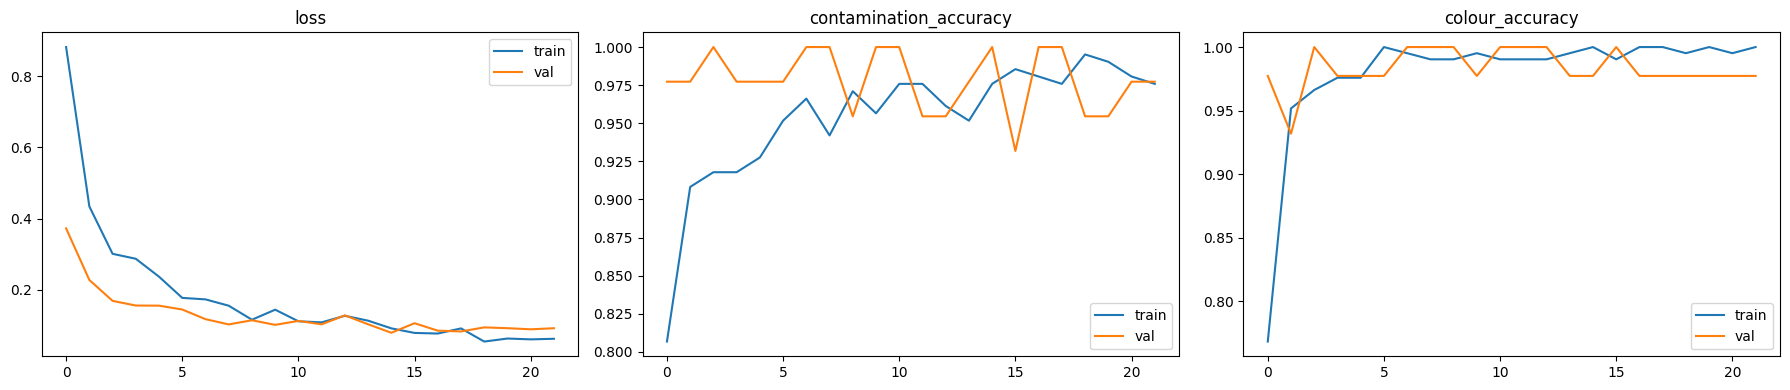

In [8]:
# ── 8. Training curve ─────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, metric in zip(axes, ['loss', 'contamination_accuracy', 'colour_accuracy']):
    ax.plot(history.history[metric], label='train')
    ax.plot(history.history[f'val_{metric}'], label='val')
    ax.set_title(metric)
    ax.legend()
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120)
plt.show()

In [9]:
# ── 9. Test seti değerlendirme ────────────────────────────────────
# Drive'daki kaydedilen en iyi modeli yükle
best_model = tf.keras.models.load_model(SAVE_PATH)

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

y_true_cont, y_true_c = [], []
y_pred_cont, y_pred_c = [], []
scores_cont, scores_c = [], []

for imgs, labels in test_ds:
    preds = best_model.predict(imgs, verbose=0)
    y_true_cont.extend(labels['contamination'].numpy().flatten())
    y_true_c.extend(labels['colour'].numpy().flatten())
    scores_cont.extend(preds[0].flatten())
    scores_c.extend(preds[1].flatten())
    y_pred_cont.extend((preds[0] > 0.5).flatten())
    y_pred_c.extend((preds[1] > 0.5).flatten())

for name, yt, yp, sc in [
    ('contamination', y_true_cont, y_pred_cont, scores_cont),
    ('colour',        y_true_c,    y_pred_c,    scores_c)
]:
    acc = accuracy_score(yt, yp)
    f1  = f1_score(yt, yp, zero_division=0)
    cm  = confusion_matrix(yt, yp)
    print(f'\n── {name} ──')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  F1 Score : {f1:.4f}')
    print(f'  Score min/max/mean: {min(sc):.3f} / {max(sc):.3f} / {np.mean(sc):.3f}')
    print(f'  Confusion matrix:\n{cm}')


── contamination ──
  Accuracy : 0.9333
  F1 Score : 0.9538
  Score min/max/mean: 0.007 / 1.000 / 0.726
  Confusion matrix:
[[11  1]
 [ 2 31]]

── colour ──
  Accuracy : 1.0000
  F1 Score : 1.0000
  Score min/max/mean: 0.000 / 1.000 / 0.489
  Confusion matrix:
[[23  0]
 [ 0 22]]


In [10]:
# ── 10. Optimal threshold ─────────────────────────────────────────
for name, yt, sc in [
    ('contamination', y_true_cont, scores_cont),
    ('colour',        y_true_c,    scores_c)
]:
    best_t, best_f1 = 0.5, 0
    for thresh in np.arange(0.05, 0.95, 0.05):
        yp = [1 if s > thresh else 0 for s in sc]
        f1 = f1_score(yt, yp, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t  = thresh
    yp_best = [1 if s > best_t else 0 for s in sc]
    acc = accuracy_score(yt, yp_best)
    print(f'{name}: best_threshold={best_t:.2f}  acc={acc:.3f}  f1={best_f1:.3f}')

contamination: best_threshold=0.55  acc=0.956  f1=0.969
colour: best_threshold=0.10  acc=1.000  f1=1.000


In [ ]:
from PIL import Image
import numpy as np
import glob, os

best_model = tf.keras.models.load_model(SAVE_PATH)

images = sorted(glob.glob('/content/test_images/*.jpg') + glob.glob('/content/test_images/*.jpeg'))

if not images:
    print('Görüntü bulunamadı — /content/*.jpg formatında kaydet')
else:
    print(f"{'Dosya':<30} {'Contamination':>15} {'Colour':>10} {'Karar'}")
    print('-' * 70)
    for path in images:
        img = Image.open(path).convert('RGB').resize((192, 192))
        arr = np.expand_dims(np.array(img, dtype=np.float32) / 255.0, axis=0)
        preds = best_model.predict(arr, verbose=0)
        cont  = float(preds[0][0][0])
        col   = float(preds[1][0][0])
        karar = []
        if cont > 0.25: karar.append('KİRLİ')
        if col  > 0.05: karar.append('RENKLİ')
        if not karar:   karar.append('TEMİZ')
        fname = os.path.basename(path)
        print(f'{fname:<30} {cont:>15.4f} {col:>10.4f}  {", ".join(karar)}')

Görüntü bulunamadı — /content/*.jpg formatında kaydet


In [13]:
# ── TFLite INT8 dönüşümü ──────────────────────────────────────────
import tensorflow as tf

# En iyi modeli Drive'dan yükle
best_model = tf.keras.models.load_model(SAVE_PATH)

TFLITE_PATH = '/content/drive/MyDrive/models/MobileNetV2_a035.tflite'

def representative_dataset():
    for imgs, _ in train_ds:
        yield [imgs]

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.uint8
converter.inference_output_type = tf.uint8

tflite_model = converter.convert()

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

print(f'Model boyutu: {len(tflite_model)/1024:.1f} KB')
print(f'Kaydedildi: {TFLITE_PATH}')

# Tensor sırasını kontrol et
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
output_details = interpreter.get_output_details()
for i, o in enumerate(output_details):
    print(f'[{i}] {o["name"]}  dtype={o["dtype"]}')

Saved artifact at '/tmp/tmp5t2masqk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  List[TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  136709549521808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709549522768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709549517200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709549521232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709549520272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709549519888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709549519504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709549522384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709549520080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136709549519120: Te

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Model boyutu: 772.2 KB
Kaydedildi: /content/drive/MyDrive/models/MobileNetV2_a035.tflite
[0] StatefulPartitionedCall_1:1  dtype=<class 'numpy.uint8'>
[1] StatefulPartitionedCall_1:0  dtype=<class 'numpy.uint8'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
import numpy as np
from PIL import Image
import tensorflow as tf
best_model = tf.keras.models.load_model(SAVE_PATH)
# JPEG'i aç ama önce uint8 array'e çevir, sonra float yap
img = Image.open("/content/con8633co1719.jpeg").convert("RGB")
arr_uint8 = np.array(img, dtype=np.uint8)
# uint8 direkt — ESP32'nin yaptığı gibi
arr_float = np.expand_dims(arr_uint8.astype(np.float32) / 255.0, axis=0)
preds = best_model.predict(arr_float, verbose=0)
print(f"contamination: {preds[0][0][0]:.4f}")
print(f"colour:        {preds[1][0][0]:.4f}")
# Ayrıca TFLite ile de test et
interpreter = tf.lite.Interpreter(model_path="/content/drive/MyDrive/wco_model_v7_int8.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
img_uint8 = np.expand_dims(arr_uint8, axis=0)
interpreter.set_tensor(input_details[0]['index'], img_uint8)
interpreter.invoke()
raw0 = interpreter.get_tensor(output_details[0]['index'])[0][0]
raw1 = interpreter.get_tensor(output_details[1]['index'])[0][0]
scale = output_details[0]['quantization'][0]
print(f"\nTFLite [0]: {int(raw0) * scale:.4f}")
print(f"TFLite [1]: {int(raw1) * scale:.4f}")

contamination: 0.9766
colour:        0.9713

TFLite [0]: 0.9922
TFLite [1]: 0.9219


In [14]:
!xxd -i /content/drive/MyDrive/models/MobileNetV2_a035.tflite > /content/drive/MyDrive/models/MobileNetV2_a035.cpp

In [ ]:
with open('/content/drive/MyDrive/models/MobileNetV2_a035.cpp', 'r') as f:
    content = f.read()

content = (
      '#include "MobileNetV1_a025.h"\n\n'
      '#ifdef __has_attribute\n#define HAVE_ATTRIBUTE(x) __has_attribute(x)\n'
      '#else\n#define HAVE_ATTRIBUTE(x) 0\n#endif\n'
      '#if HAVE_ATTRIBUTE(aligned) || (defined(__GNUC__) && !defined(__clang__))\n'
      '#define DATA_ALIGN_ATTRIBUTE __attribute__((aligned(4)))\n'
      '#else\n#define DATA_ALIGN_ATTRIBUTE\n#endif\n\n'
      + content
      .replace('unsigned char wco_model_v2_int8_tflite[]',
               'const unsigned char g_model_int8_data[] DATA_ALIGN_ATTRIBUTE')
      .replace('unsigned int _content_drive_MyDrive_wco_model_v7_int8_tflite_len',
               'const int g_model_int8_data_len')
  )

with open('/content/wco_model_data.cpp', 'w') as f:
      f.write(content)

print('Hazır:', '/content/wco_model_data.cpp')

Hazır: /content/wco_model_data.cpp
